## CNN on MNIST — 卷积神经网络手写数字识别

### 为什么需要 CNN？

MLP 把 28×28 图片展平为 784 维向量，**完全丢失了空间结构**：相邻像素和远距离像素在展平后"一视同仁"，数字移动几个像素输出就剧变。

CNN 通过**卷积核**在图片上滑动扫描，天然具备两个优势：
1. **平移不变性** — 同一个卷积核扫过整张图，数字移到哪都能识别
2. **参数共享** — 一个 3×3 卷积核只有 9 个参数，而不是 784 个

### CNN 数据流

```
输入 (N, 1, 28, 28)                    ← 保持二维图像结构
  │
  ▼
Conv Block 1: Conv3×3(1→32)×2 → BN → ReLU → MaxPool(2) → 14×14
  │
  ▼
Conv Block 2: Conv3×3(32→64)×2 → BN → ReLU → MaxPool(2) → 7×7
  │
  ▼
Flatten → FC(64×7×7, 128) → FC(128, 10)  ← 分类头
```

> 对比基线：MLP 测试准确率约 98.6%（537K 参数），CNN 仅用 ~120K 参数即可达到 ~99.3%+。

## 1. 导入依赖与数据加载

CNN 的输入保持 `(N, 1, 28, 28)` 图像格式，不展平，保留空间结构。

In [1]:
# [1.1 导入依赖]
# CNN 输入保持 (N,1,28,28) 图像格式，不展平，保留空间结构
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
import warnings
warnings.filterwarnings('ignore')

# ==== 中文字体配置 ====
# matplotlib 默认不支持中文，需手动指定支持中文的字体
# 优先级：微软雅黑 > 黑体 > DejaVu Sans（英文回退）
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False  # 防止负号显示为方块

%matplotlib inline
%config InlineBackend.figure_format = 'retina'

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'设备: {device}')

设备: cuda


In [2]:
# [1.2 加载 MNIST 数据]
# CNN 输入格式: (N, C, H, W) = (N, 1, 28, 28)
# unsqueeze(1) 在第 1 维插入通道维度
mnist = fetch_openml(
    name="mnist_784", version=1, as_frame=False,
    cache=True, data_home="../data"
)
X = mnist.data.reshape(-1, 28, 28).astype(np.uint8)
y = mnist.target.astype(np.uint8)
X_train, X_test = X[:60000], X[60000:]
y_train, y_test = y[:60000], y[60000:]

# 转为 PyTorch 张量：添加通道维度 (N,1,28,28) 并归一化到 [0,1]
X_train_t = torch.tensor(X_train, dtype=torch.float32).unsqueeze(1) / 255.0
X_test_t  = torch.tensor(X_test,  dtype=torch.float32).unsqueeze(1) / 255.0
y_train_t = torch.tensor(y_train, dtype=torch.long)
y_test_t  = torch.tensor(y_test,  dtype=torch.long)

# ======== 超参数集中修改区 ========
BATCH_SIZE = 64
# =================================

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(TensorDataset(X_test_t,  y_test_t),  batch_size=BATCH_SIZE, shuffle=False)

print(f'训练批次数: {len(train_loader)}, 测试批次数: {len(test_loader)}')
print(f'输入形状: {X_train_t.shape}')  # (60000, 1, 28, 28)

训练批次数: 938, 测试批次数: 157
输入形状: torch.Size([60000, 1, 28, 28])


## 2. 理解卷积操作

### 卷积核如何工作？

```
    3×3 卷积核在图片上滑动

    ┌───┬───┬───┐
    │ 1 │ 0 │ 1 │      ┌───┬───┬───┐
    ├───┼───┼───┤      │ a │ b │ c │
    │ 0 │ 1 │ 0 │  ✕   ├───┼───┼───┤  = 1×a + 0×b + 1×c + ...
    ├───┼───┼───┤      │ d │ e │ f │     (加权求和)
    │ 1 │ 0 │ 1 │      ├───┼───┼───┤
    └───┴───┴───┘      │ g │ h │ i │
    卷积核 (权重)       └───┴───┴───┘
                       图片局部区域
```

### 各组件的作用

| 组件 | 作用 | 通俗理解 |
|------|------|----------|
| `Conv2d(1→32, 3×3)` | 32 个 3×3 卷积核 | 32 个人同时看 3×3 窗口，各看各的 |
| `BatchNorm2d` | 归一化每个通道 | 让每个卷积核的输出"站"在同一个起跑线 |
| `ReLU` | 非线性激活 | 负的不要，只留正的 |
| `MaxPool2d(2)` | 2×2 窗口取最大值 | 尺寸减半，保留最强信号 |
| `Dropout2d` | 随机丢弃整个通道 | 强迫网络不依赖某一个卷积核 |

### 关键设计：自动计算展平维度

```python
final_spatial = 28 // (2 ** 2) = 7    # 两次 MaxPool 后尺寸
flatten_dim = 64 × 7 × 7 = 3136      # 自动算出，改通道数/层数无需手算
```

In [3]:
# [2. 定义 CNN 模型]
class SimpleCNN(nn.Module):
    """
    轻量级 CNN — 可配置的卷积 Block + 全连接分类头

    每个 Block = N×Conv2d → BatchNorm2d → ReLU → MaxPool2d → Dropout2d
    展平维度自动计算，改通道数/层数无需手算

    可调参数（保留默认值即可运行）:
        conv_channels: 每层输出通道列表，默认 [32, 64]
        conv_per_block: 每个 Block 卷积数，默认 2
        kernel_size: 卷积核大小，默认 3
        fc_hidden: 全连接隐藏维度，默认 128
    """
    def __init__(self, num_classes=10, dropout=0.3,
                 conv_channels=None,
                 conv_per_block=2,
                 kernel_size=3,
                 fc_hidden=128,
                 in_channels=1,
                 input_size=28):
        super(SimpleCNN, self).__init__()

        if conv_channels is None:
            conv_channels = [32, 64]

        in_ch = in_channels                     # 当前输入通道数（随 Block 更新）
        self.conv_blocks = nn.ModuleList()       # ModuleList: 保存子模块列表

        # ==== 逐层构建卷积 Block ====
        # 每个 Block 内部: N 个 Conv2d(same padding) → MaxPool2d(2)→Dropout2d
        # 每个 Block 之后空间尺寸减半
        for out_ch in conv_channels:
            layers = []
            for j in range(conv_per_block):
                # padding=kernel//2 保持空间尺寸不变（same padding）
                layers.extend([
                    nn.Conv2d(in_ch if j == 0 else out_ch, out_ch,
                              kernel_size=kernel_size,
                              padding=kernel_size // 2),
                    nn.BatchNorm2d(out_ch),       # 通道级归一化
                    nn.ReLU(),                    # 非线性激活
                ])
            # 每个 Block 末尾：池化(降采样) + Dropout(正则化)
            layers.extend([nn.MaxPool2d(2), nn.Dropout2d(dropout)])
            self.conv_blocks.append(nn.Sequential(*layers))
            in_ch = out_ch                        # 更新当前通道数

        # ==== 自动计算展平维度 ====
        # 每次 MaxPool2d(2) 尺寸减半: 28→14→7（两个 Block）
        final_spatial = input_size // (2 ** len(conv_channels))  # 28//4 = 7
        flatten_dim = conv_channels[-1] * final_spatial * final_spatial  # 64×7×7=3136

        # ==== 全连接分类头 ====
        self.classifier = nn.Sequential(
            nn.Flatten(),                              # (B,64,7,7)→(B,3136)
            nn.Linear(flatten_dim, fc_hidden),         # (B,3136)→(B,128)
            nn.BatchNorm1d(fc_hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(fc_hidden, num_classes)          # (B,128)→(B,10)
        )

    def forward(self, x):
        # 1. 逐 Block 前向: (B,1,28,28)→Block1→(B,32,14,14)→Block2→(B,64,7,7)
        for block in self.conv_blocks:
            x = block(x)
        # 2. 全连接分类: Flatten→FC→logits (B,10)
        x = self.classifier(x)
        return x


# 实例化模型
model = SimpleCNN(num_classes=10, dropout=0.3).to(device)

# ==== 调参示例（取消注释即可尝试）====
# 更宽: model = SimpleCNN(num_classes=10, dropout=0.3, conv_channels=[64, 128]).to(device)
# 更深: model = SimpleCNN(num_classes=10, dropout=0.3, conv_channels=[32, 64, 128]).to(device)
# 更大核: model = SimpleCNN(num_classes=10, dropout=0.3, kernel_size=5).to(device)
# ====================================

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'总参数量: {total_params:,}')
print(f'可训练参数量: {trainable_params:,}')
print()
print(model)

总参数量: 468,458
可训练参数量: 468,458

SimpleCNN(
  (conv_blocks): ModuleList(
    (0): Sequential(
      (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU()
      (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (7): Dropout2d(p=0.3, inplace=False)
    )
    (1): Sequential(
      (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU()
      (6)

## 3. 损失函数与优化器

- **Adam**：自适应学习率，对 CNN 也很稳定
- **Weight Decay=1e-4**：L2 正则化
- **ReduceLROnPlateau**：监控验证 loss，自动衰减学习率

In [4]:
# [3. 损失函数 + 优化器 + 学习率调度器]
# Adam + ReduceLROnPlateau：稳定可靠的训练配置

# ======== 超参数集中修改区 ========
LR = 0.001
WEIGHT_DECAY = 1e-4
SCHEDULER_FACTOR = 0.5
SCHEDULER_PATIENCE = 5
# =================================

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=SCHEDULER_FACTOR,
    patience=SCHEDULER_PATIENCE, verbose=True
)

print(f'优化器: Adam(lr={LR}, weight_decay={WEIGHT_DECAY})')
print(f'调度器: ReduceLROnPlateau(factor={SCHEDULER_FACTOR}, patience={SCHEDULER_PATIENCE})')

优化器: Adam(lr=0.001, weight_decay=0.0001)
调度器: ReduceLROnPlateau(factor=0.5, patience=5)


## 4. 训练与评估函数

训练流程与 MLP 完全相同——PyTorch 的 `nn.Module` 抽象让我们可以复用相同的训练代码。

In [5]:
# [4. 训练/评估函数]
def train_one_epoch(model, loader, criterion, optimizer, device):
    """训练一个 epoch，返回 (avg_loss, accuracy)"""
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        # 标准训练五步
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)
    return total_loss / total, correct / total


def evaluate(model, loader, criterion, device):
    """评估模型，返回 (avg_loss, accuracy)"""
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)
    return total_loss / total, correct / total

## 5. 启动训练

训练 50 个 epoch。自动保存最佳模型（`best.pth`）和周期性 checkpoint。

In [6]:
# [5. 训练循环]

# ======== 超参数集中修改区 ========
EPOCHS = 50
CHECKPOINT_INTERVAL = 10   # 每 10 个 epoch 保存一次 checkpoint
SAVE_DIR = '../models/cnn'
# =================================

history = {
    'train_loss': [], 'train_acc': [],
    'test_loss': [],  'test_acc': []
}

best_test_acc = 0.0
best_epoch = 0

for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = train_one_epoch(
        model, train_loader, criterion, optimizer, device
    )
    test_loss, test_acc = evaluate(
        model, test_loader, criterion, device
    )

    scheduler.step(test_loss)

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['test_loss'].append(test_loss)
    history['test_acc'].append(test_acc)

    # 保存最优模型
    if test_acc > best_test_acc:
        best_test_acc = test_acc
        best_epoch = epoch
        torch.save(model.state_dict(), f'{SAVE_DIR}/best.pth')

    # 定期保存检查点
    if epoch % CHECKPOINT_INTERVAL == 0:
        torch.save(model.state_dict(), f'{SAVE_DIR}/epoch_{epoch}.pth')
        print(f'  [checkpoint] 已保存: cnn_epoch_{epoch}.pth')

    # 每 5 个 epoch 或第 1 个 epoch 打印进度
    if epoch % 5 == 0 or epoch == 1:
        print(
            f'Epoch [{epoch:3d}/{EPOCHS}] '
            f'Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | '
            f'Test Loss:  {test_loss:.4f} | Test Acc:  {test_acc:.4f}'
        )

print(f'\n训练完成！最佳测试准确率: {best_test_acc:.4f} (Epoch {best_epoch})')

Epoch [  1/50] Train Loss: 0.1676 | Train Acc: 0.9571 | Test Loss:  0.0326 | Test Acc:  0.9898
Epoch [  5/50] Train Loss: 0.0394 | Train Acc: 0.9880 | Test Loss:  0.0182 | Test Acc:  0.9938
  [checkpoint] 已保存: cnn_epoch_10.pth
Epoch [ 10/50] Train Loss: 0.0298 | Train Acc: 0.9908 | Test Loss:  0.0151 | Test Acc:  0.9950
Epoch [ 15/50] Train Loss: 0.0252 | Train Acc: 0.9922 | Test Loss:  0.0178 | Test Acc:  0.9945
  [checkpoint] 已保存: cnn_epoch_20.pth
Epoch [ 20/50] Train Loss: 0.0256 | Train Acc: 0.9919 | Test Loss:  0.0154 | Test Acc:  0.9953
Epoch [ 25/50] Train Loss: 0.0236 | Train Acc: 0.9924 | Test Loss:  0.0150 | Test Acc:  0.9944
  [checkpoint] 已保存: cnn_epoch_30.pth
Epoch [ 30/50] Train Loss: 0.0142 | Train Acc: 0.9959 | Test Loss:  0.0146 | Test Acc:  0.9946
Epoch [ 35/50] Train Loss: 0.0095 | Train Acc: 0.9971 | Test Loss:  0.0129 | Test Acc:  0.9962
  [checkpoint] 已保存: cnn_epoch_40.pth
Epoch [ 40/50] Train Loss: 0.0075 | Train Acc: 0.9980 | Test Loss:  0.0139 | Test Acc:  0.99

## 6. 训练曲线可视化

左侧 Loss 曲线观察收敛情况，右侧 Accuracy 曲线用虚线标出最佳准确率。
CNN 的 train-test gap 通常比 MLP 小得多，说明泛化能力更强。

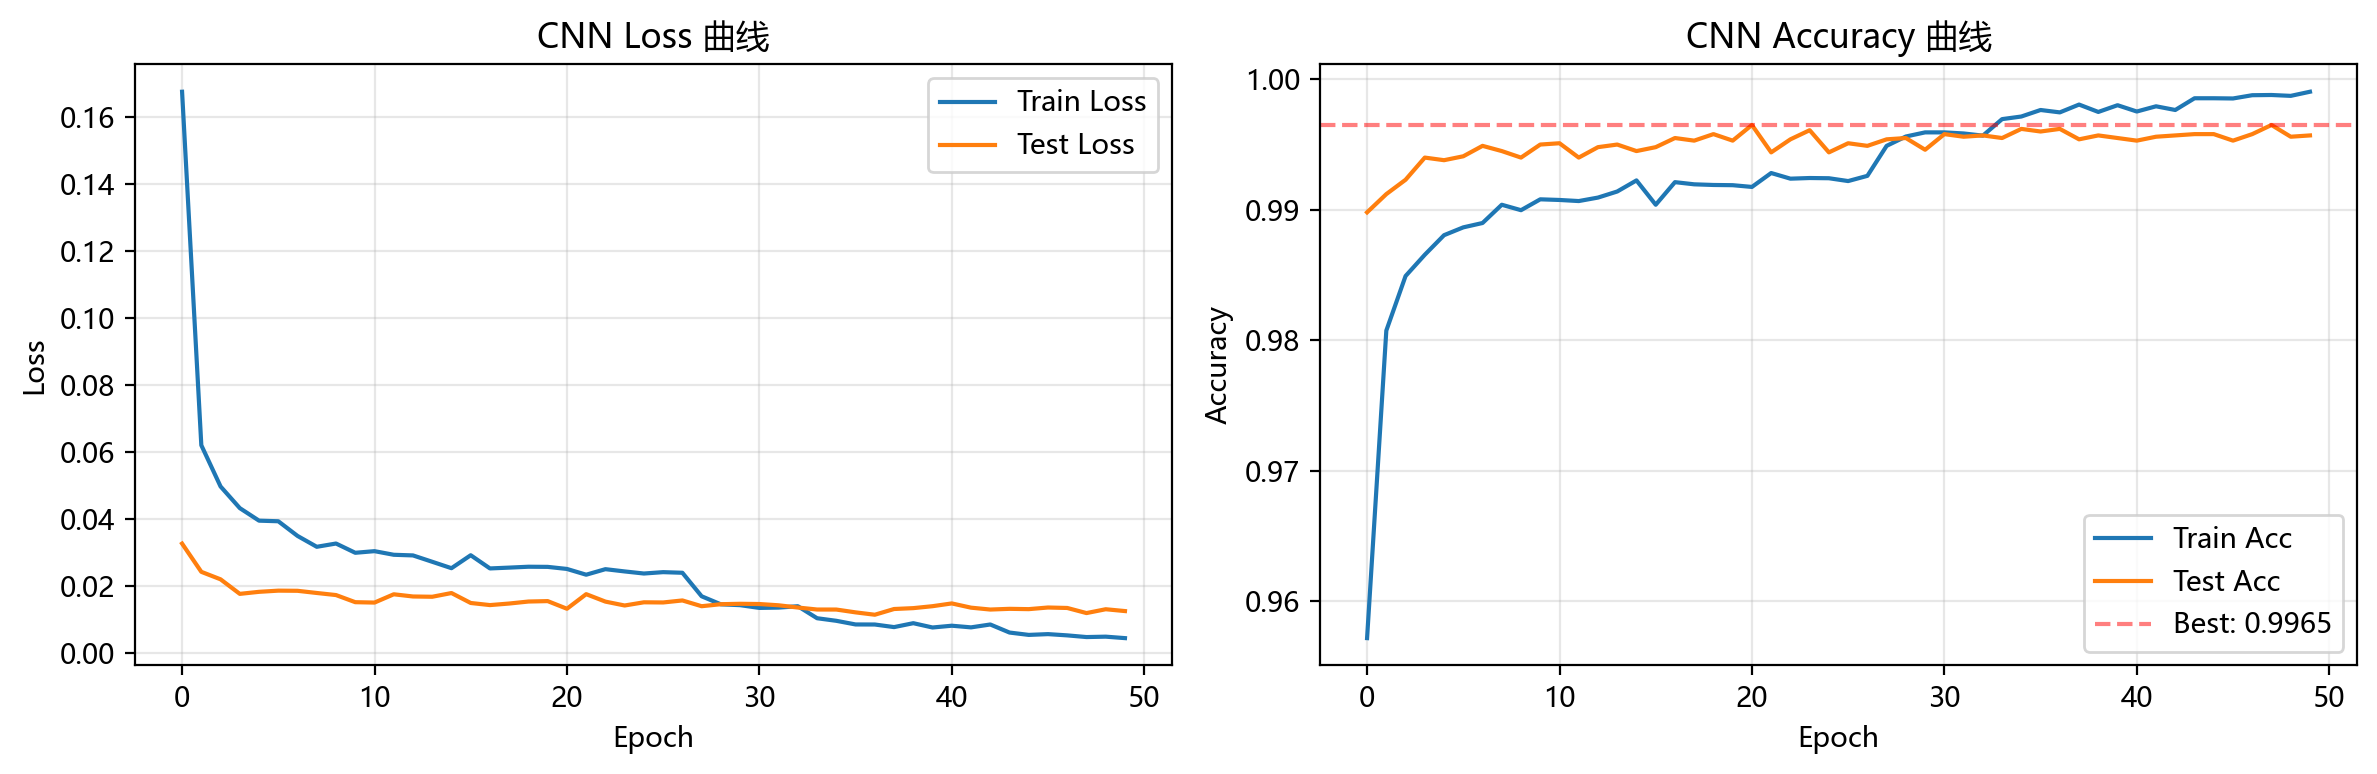

In [7]:
# [6. 训练曲线可视化]
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 左图：Loss 曲线
axes[0].plot(history['train_loss'], label='Train Loss')
axes[0].plot(history['test_loss'], label='Test Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('CNN Loss 曲线')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 右图：Accuracy 曲线
axes[1].plot(history['train_acc'], label='Train Acc')
axes[1].plot(history['test_acc'], label='Test Acc')
axes[1].axhline(y=best_test_acc, color='r', linestyle='--', alpha=0.5,
                label=f'Best: {best_test_acc:.4f}')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('CNN Accuracy 曲线')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Grad-CAM 可视化：模型「在看哪里」

Grad-CAM（Gradient-weighted Class Activation Mapping）是一种**模型可解释性**技术：

```
输入图片 → CNN 前向传播 → 提取最后一层卷积特征图 (activations)
                        → 计算类别分数对特征图的梯度 (gradients)
                        → 全局平均池化梯度 → 通道权重
                        → 加权组合特征图 → ReLU → 热力图
```

**核心思想**：热力图中「红/黄」区域是模型做分类决策时**最关注的像素区域**。
- 如果热力图聚集在数字笔画上 → 模型学到了正确的结构特征
- 如果热力图散落在背景上 → 模型可能存在过拟合或学到了无关特征

> 参考：Selvaraju et al., "Grad-CAM: Visual Explanations from Deep Networks via Gradient-based Localization", ICCV 2017

Model loaded. Parameters: 468,458
Target layer: Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))


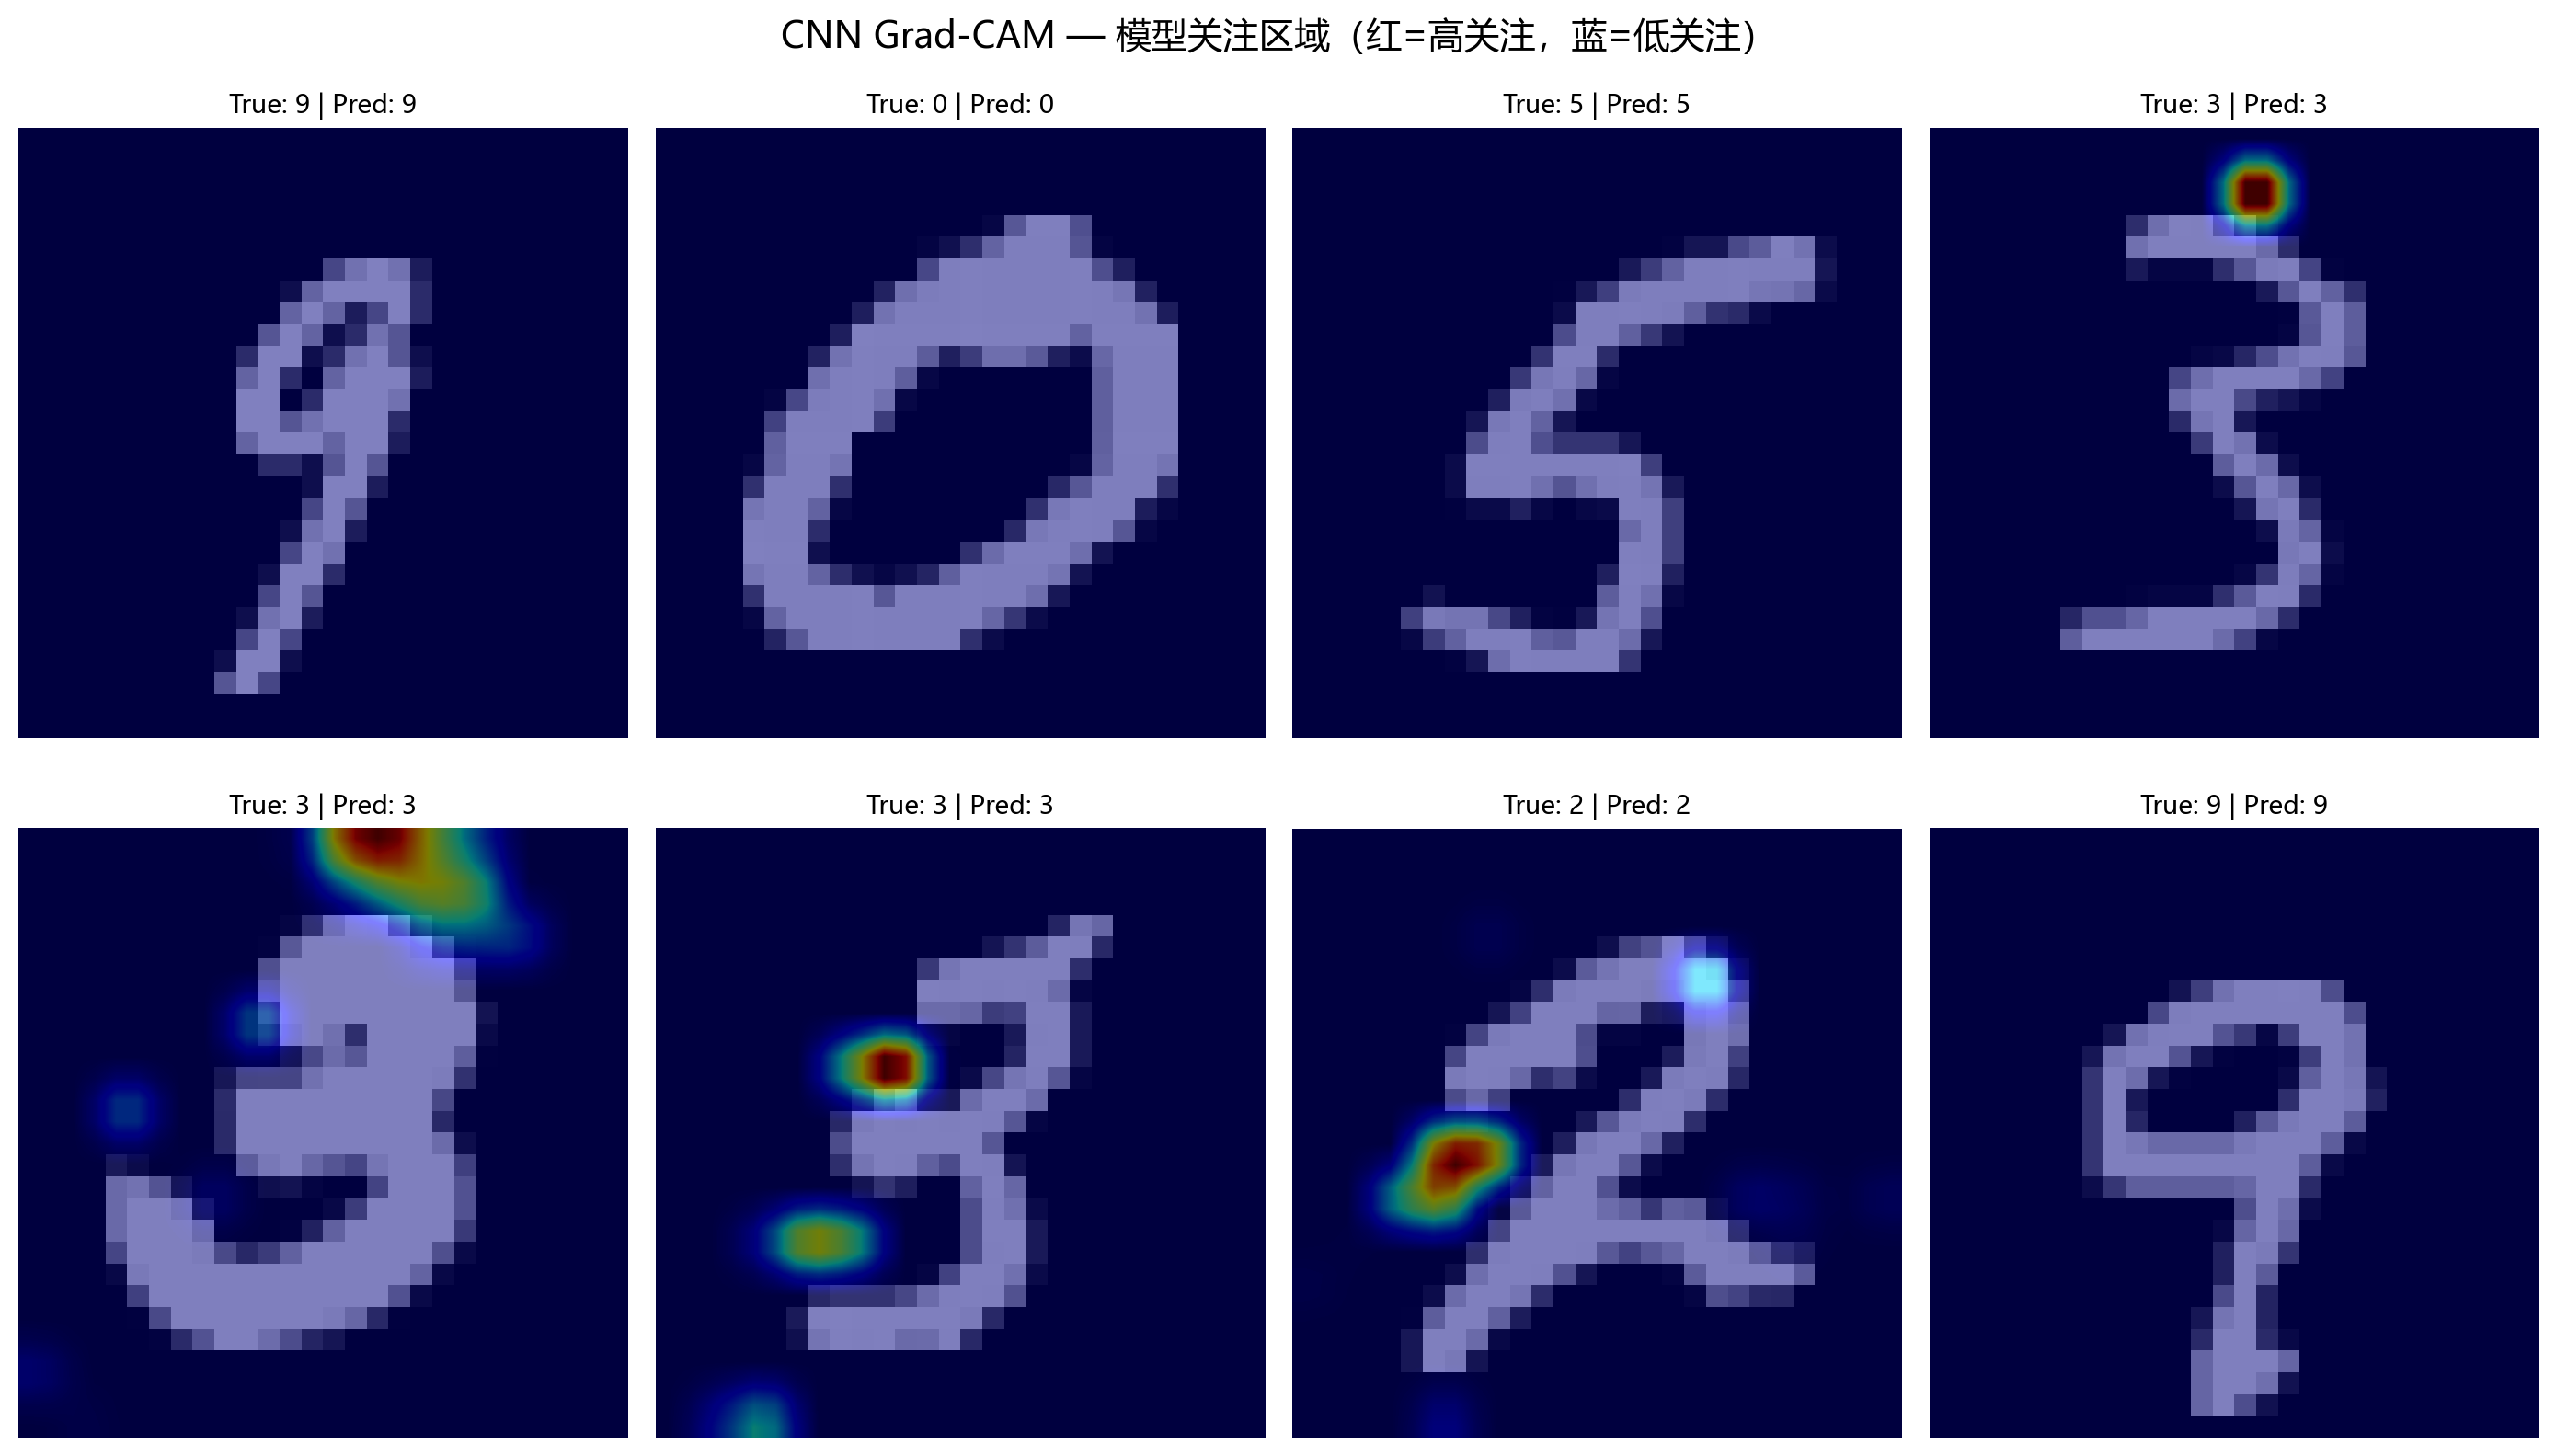

In [8]:
# [7.1 CNN Grad-CAM 热力图]
import sys
sys.path.append('..')
from utils.gradcam import GradCAM, get_cnn_target_layer, plot_gradcam, plot_multi_gradcam, tensor_to_img
import matplotlib.pyplot as plt
import torch

# 重新实例化模型并加载训练好的权重
model = SimpleCNN(in_channels=1, num_classes=10).to(device)
model.load_state_dict(torch.load('../models/cnn/best.pth', map_location=device))
model.eval()
print(f'Model loaded. Parameters: {sum(p.numel() for p in model.parameters()):,}')

# 获取 Grad-CAM 目标层（最后一个卷积层的最后一个 Conv2d）
target_layer = get_cnn_target_layer(model)
print(f'Target layer: {target_layer}')

# 创建 GradCAM 实例
gradcam = GradCAM(model, target_layer)

# 选择 8 张测试图片，计算 Grad-CAM
num_samples = 8
X_test_img = torch.tensor(X_test.reshape(-1, 1, 28, 28)).float() / 255.0
indices = torch.randperm(len(X_test_img))[:num_samples]

images, heatmaps, labels_true, labels_pred = [], [], [], []
for idx in indices:
    img_tensor = X_test_img[idx].to(device)
    heatmap, pred = gradcam(img_tensor, target_class=y_test[idx])
    images.append(tensor_to_img(img_tensor.cpu()))
    heatmaps.append(heatmap)
    labels_true.append(y_test[idx])
    labels_pred.append(pred)

gradcam.remove_hooks()

# 可视化多张 Grad-CAM 热力图
fig = plot_multi_gradcam(images, heatmaps, labels=labels_true, preds=labels_pred, 
                         ncols=4, figsize=(14, 8))
fig.suptitle('CNN Grad-CAM — 模型关注区域（红=高关注，蓝=低关注）', fontsize=14, y=1.02)
plt.show()

### 7.2 特征图可视化

除了 Grad-CAM 热力图，我们还可以直接观察**中间层特征图**：
- 浅层特征图：检测边缘、纹理等低级特征
- 深层特征图：检测语义更丰富的抽象特征

每个通道相当于一个「检测器」，对不同视觉模式作出响应。

True label: 7
Predicted: 7

--- 浅层特征图 (conv_blocks.0) ---
Shape: torch.Size([1, 32, 14, 14])  (batch, channels, height, width)


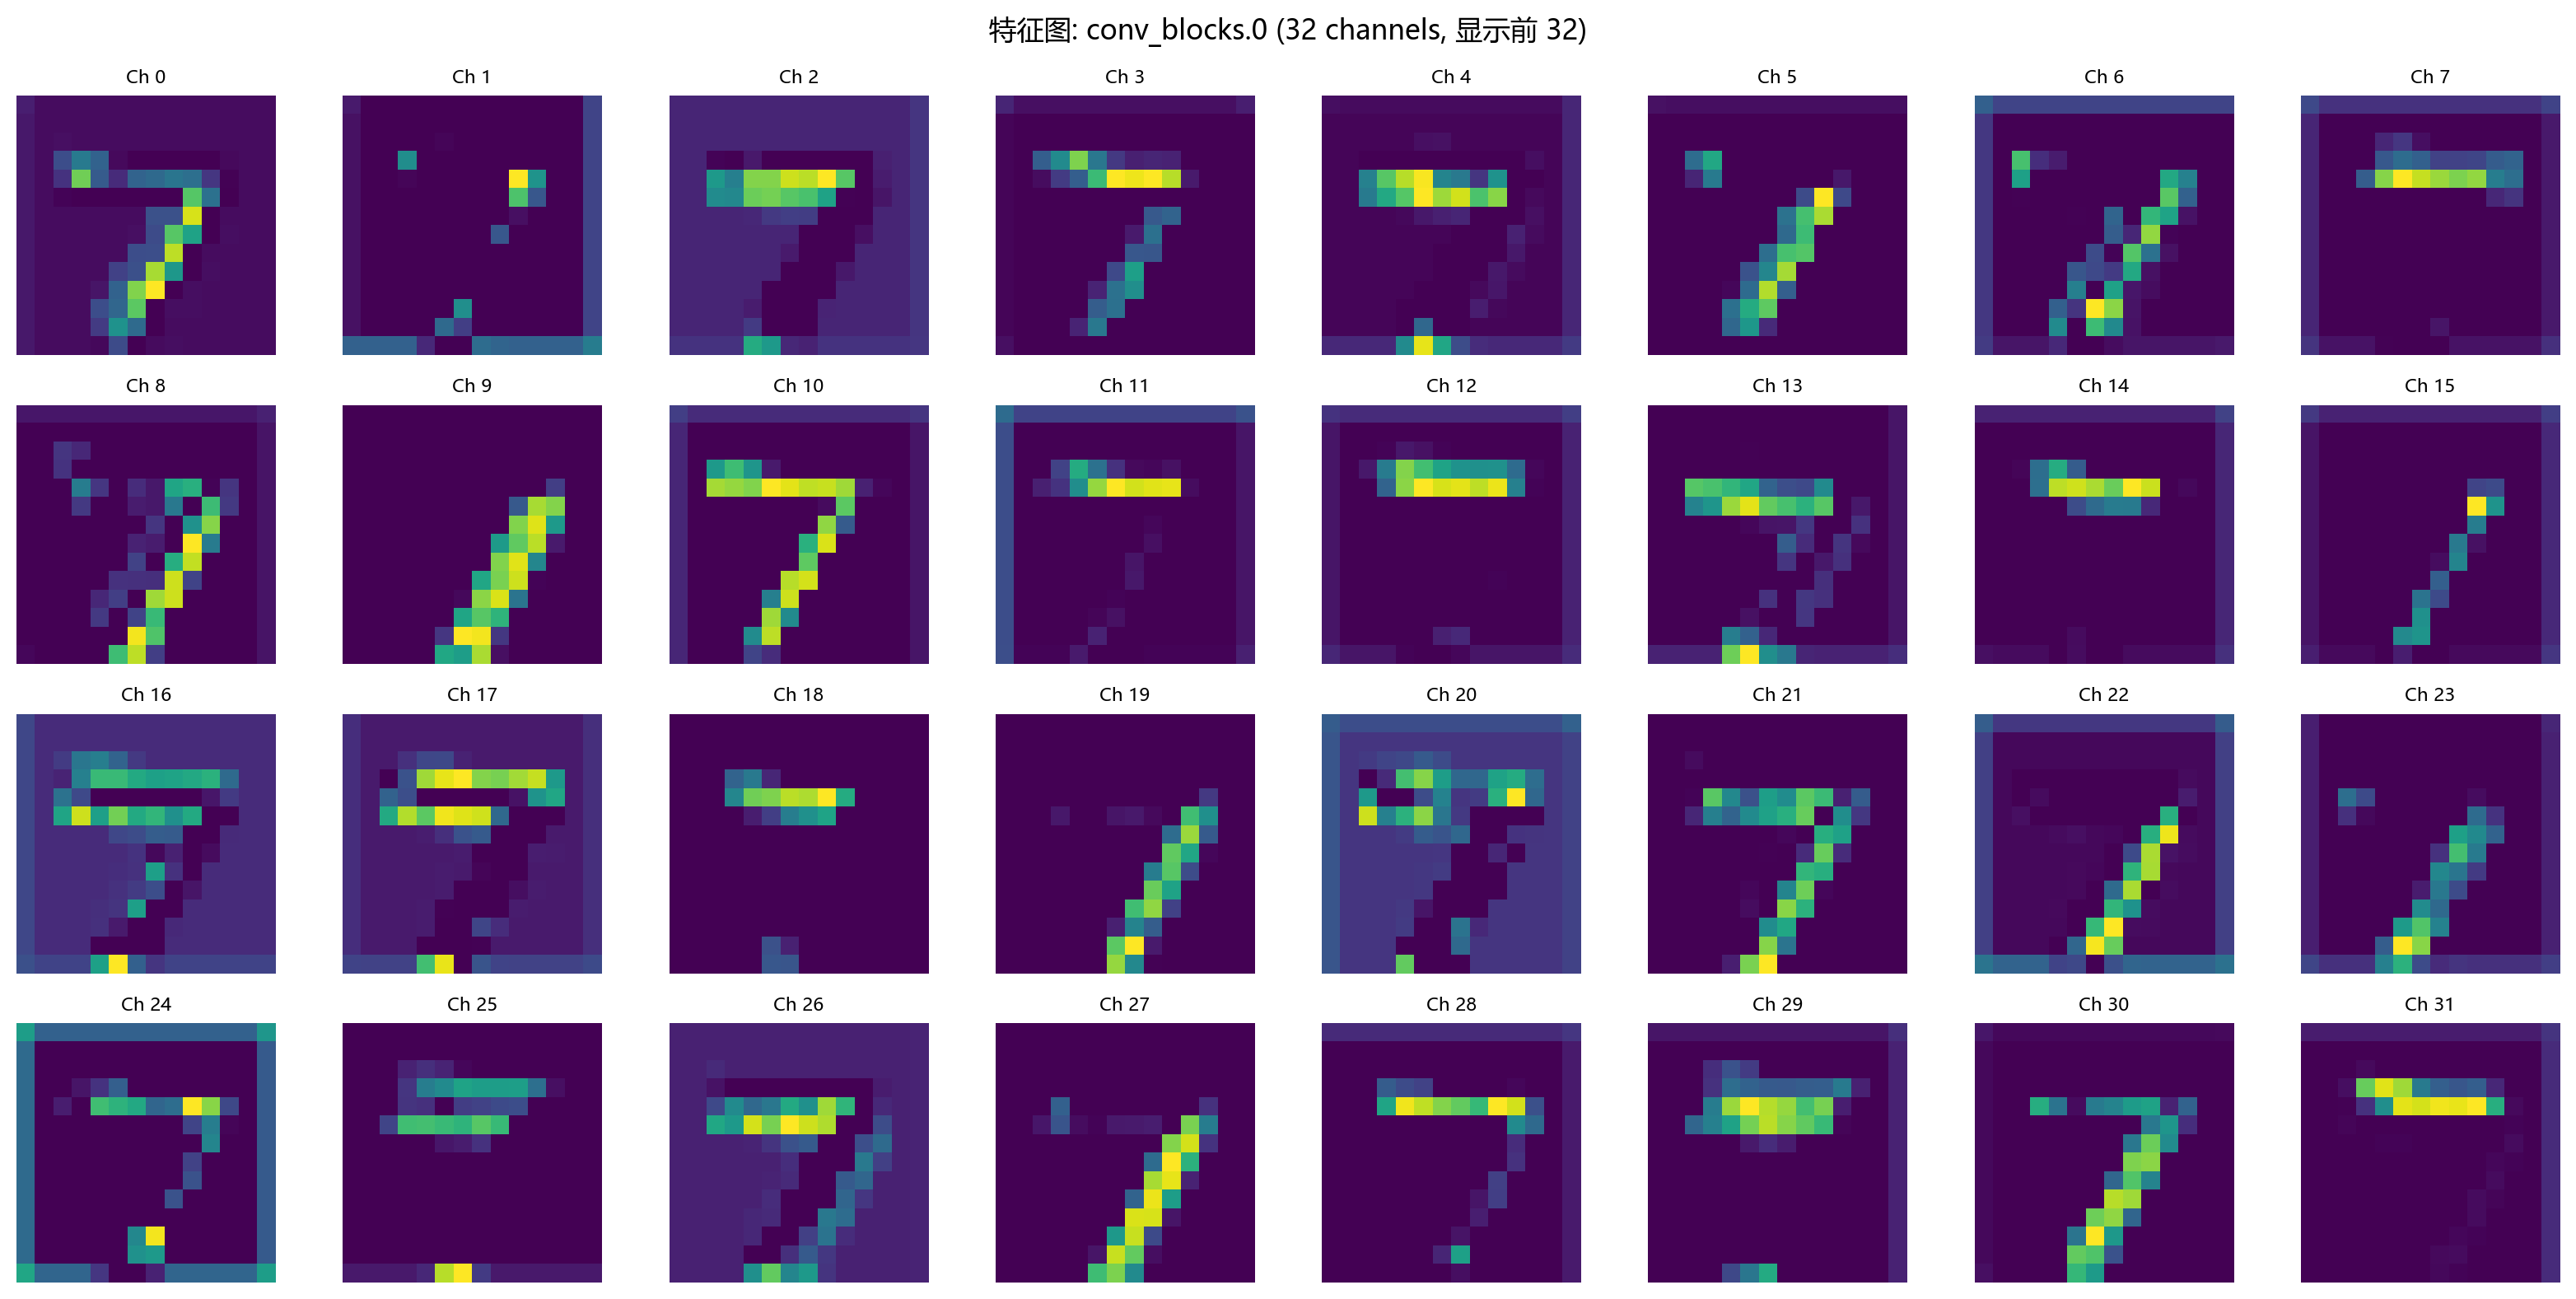


--- 深层特征图 (conv_blocks.1) ---
Shape: torch.Size([1, 64, 7, 7])  (batch, channels, height, width)


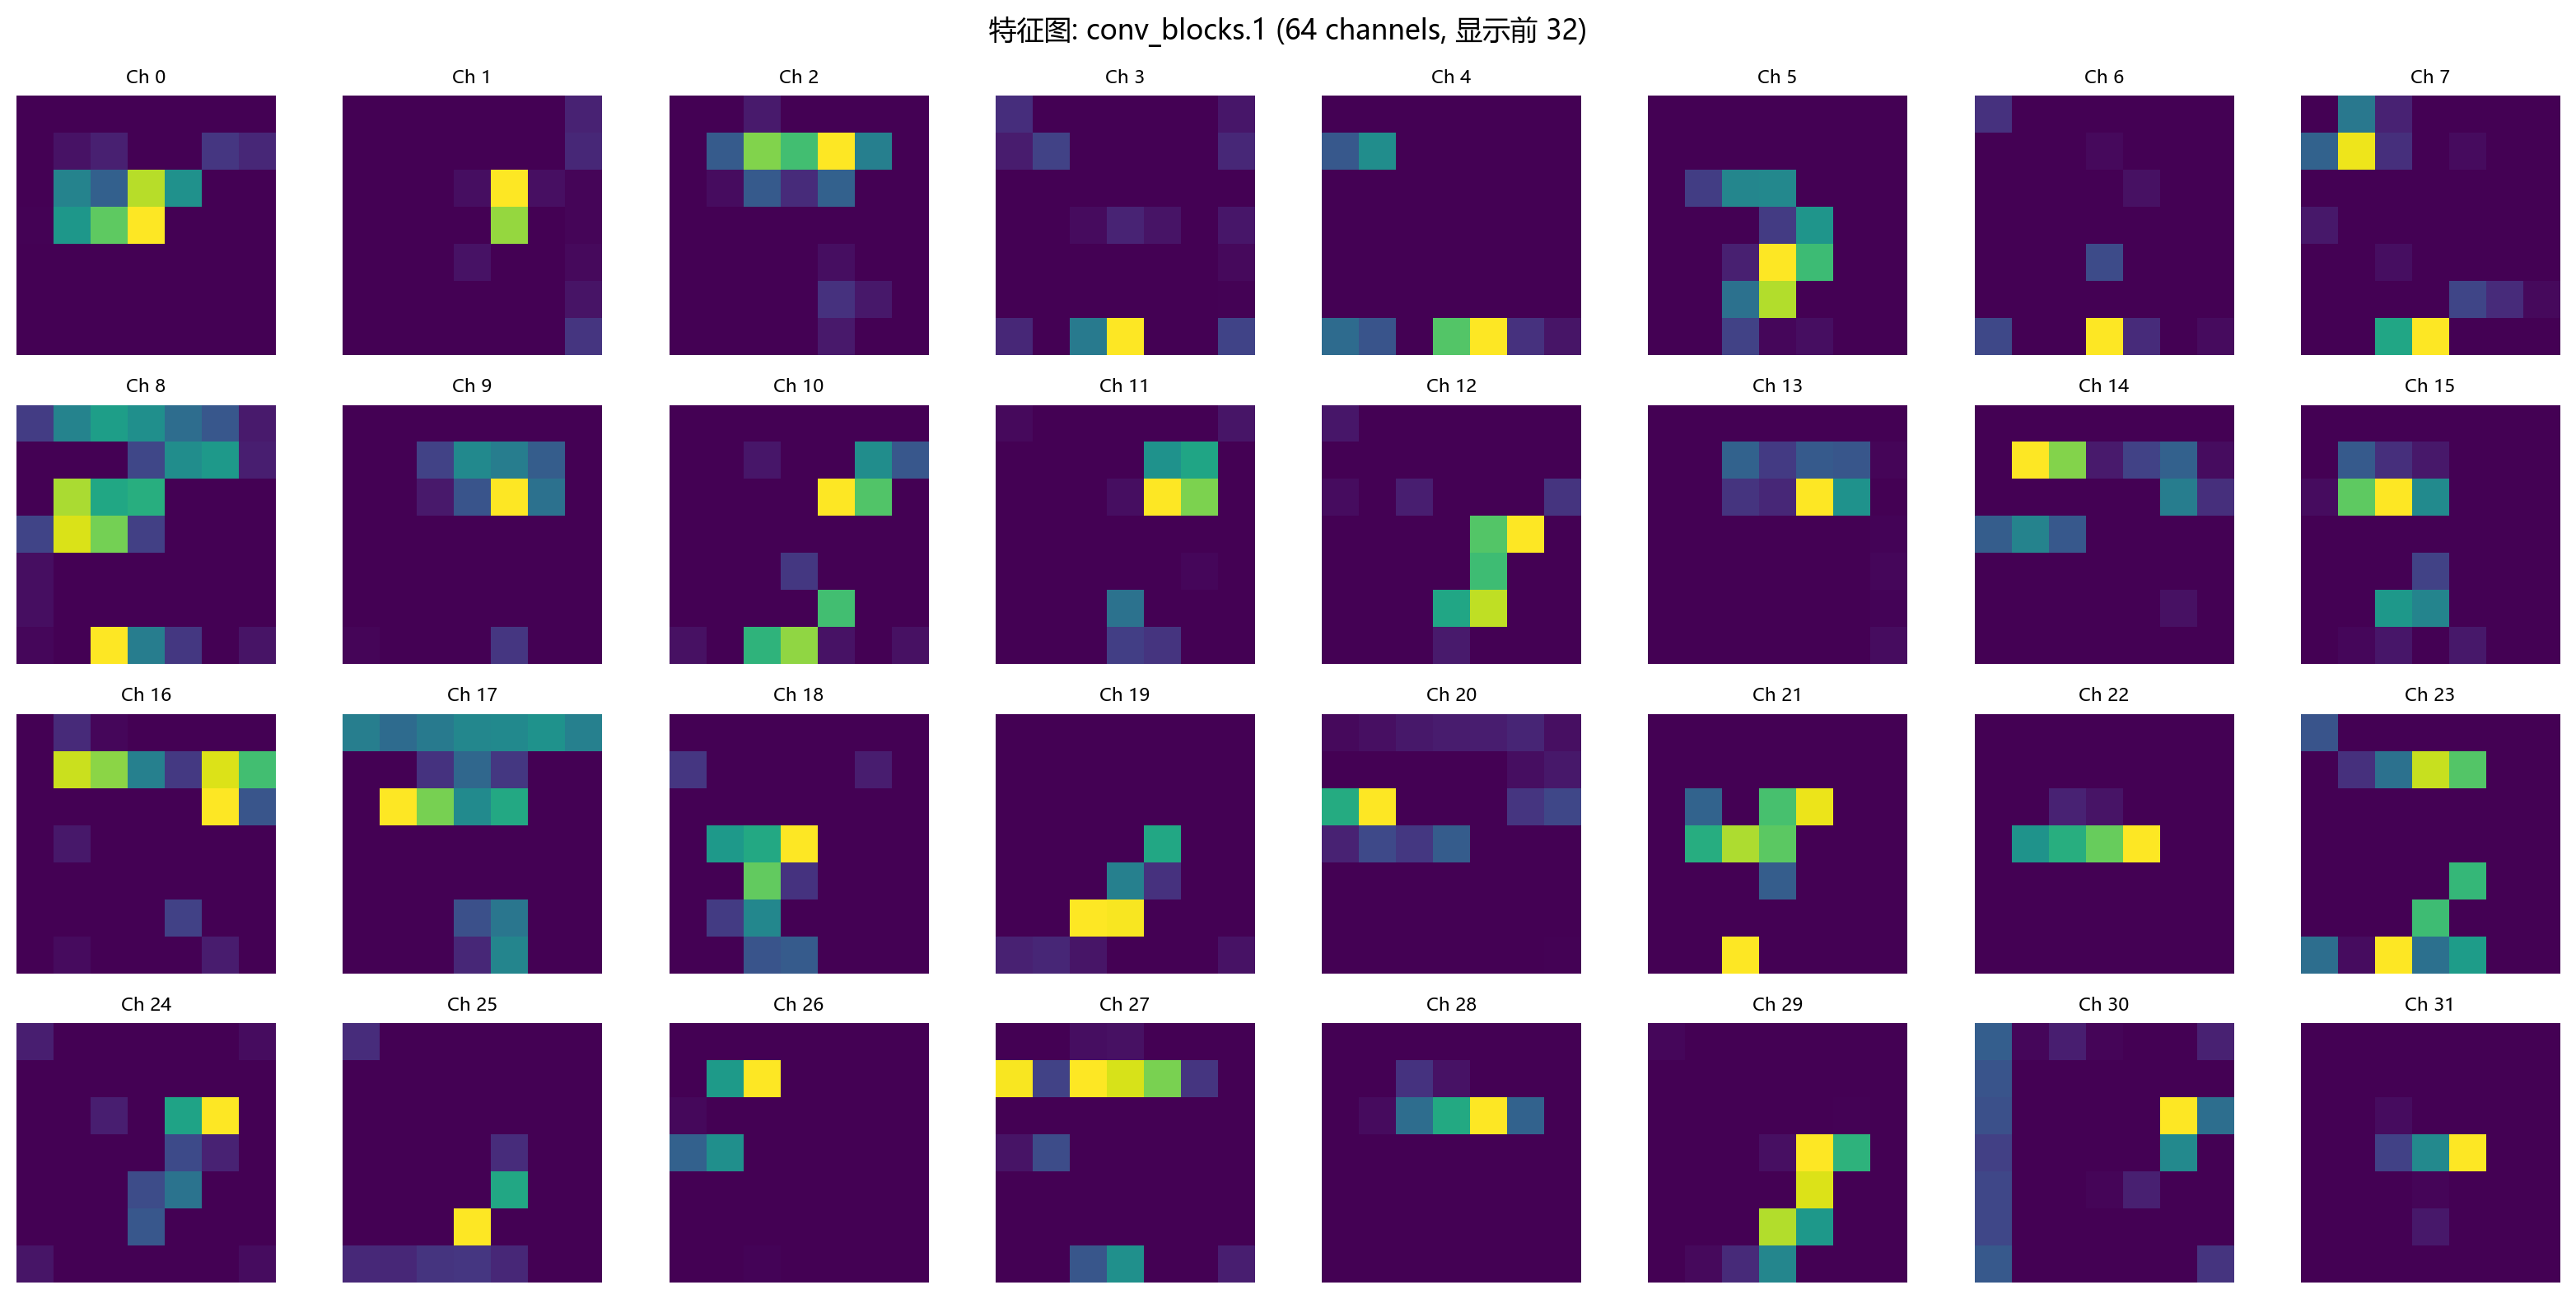


观察要点：
  • 浅层特征图保留了更多边缘和细节信息
  • 深层特征图更加抽象，通道已经难以直观解释
  • 深层特征图分辨率更低（经过 2 次 MaxPool，从 28×28 → 7×7）


In [9]:
# [7.2 CNN 特征图可视化]
from utils.gradcam import get_feature_maps, plot_feature_maps

# 选择一张测试图片
sample_idx = 0
sample_img = X_test_img[sample_idx:sample_idx+1].to(device)

# 提取各层特征图：conv_blocks[0]（浅层） 和 conv_blocks[1]（深层）
# 因为 ModuleList 内部索引在 named_modules 中为 conv_blocks.0, conv_blocks.1
feature_maps = get_feature_maps(model, sample_img, 
                                layer_names=['conv_blocks.0', 'conv_blocks.1'])

print(f'True label: {y_test[sample_idx]}')
with torch.no_grad():
    logits = model(sample_img)
    print(f'Predicted: {logits.argmax(dim=1).item()}')

# 可视化浅层特征图
print('\n--- 浅层特征图 (conv_blocks.0) ---')
print(f'Shape: {feature_maps["conv_blocks.0"].shape}  (batch, channels, height, width)')
fig1 = plot_feature_maps(feature_maps, 'conv_blocks.0', ncols=8)
plt.show()

# 可视化深层特征图
print('\n--- 深层特征图 (conv_blocks.1) ---')
print(f'Shape: {feature_maps["conv_blocks.1"].shape}  (batch, channels, height, width)')
fig2 = plot_feature_maps(feature_maps, 'conv_blocks.1', ncols=8)
plt.show()

print('\n观察要点：')
print('  • 浅层特征图保留了更多边缘和细节信息')
print('  • 深层特征图更加抽象，通道已经难以直观解释')
print('  • 深层特征图分辨率更低（经过 2 次 MaxPool，从 28×28 → 7×7）')

### 7.3 解读与分析

**我能从 Grad-CAM 中学到什么？**

| 观察 | 含义 |
|------|------|
| 热力区域集中在数字笔画上 | ✓ 模型学到了正确的结构性特征 |
| 热力区域覆盖了整个数字 | 模型的注意力范围合理 |
| 热力区域散落在背景上 | ✗ 模型可能学到了噪声/无关特征 |
| 错误预测的热力图偏离数字 | ✗ 模型「看」到了错误的位置 |
| 浅层特征图保留细节边缘 | 低层检测器正常工作 |
| 深层特征图变得更抽象 | 层级抽象正在发生 |

**Grad-CAM 的局限**：
- 只能解释卷积网络（需要梯度反向传播到特征图）
- 定位精度受限于特征图的空间分辨率
- 不能解释「为什么」——只能说明「在哪里」

## 8. 进一步学习

1. 修改 `conv_channels` 和 `kernel_size`，观察参数量和精度的变化
2. 对比 [02_mlp_training.ipynb](02_mlp_training.ipynb) 的 MLP 结果，理解架构差异的影响
3. 进入 [06_resnet_mnist.ipynb](06_resnet_mnist.ipynb) 学习残差连接如何让更深的网络可训练